## Exploratory Data Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("consolidated_logistics_base.parquet")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110196 entries, 0 to 110195
Data columns (total 70 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110196 non-null  datetime64[us]
 1   order_estimated_delivery_date  110196 non-null  datetime64[us]
 2   seller_id                      110196 non-null  str           
 3   shipping_limit_date            110196 non-null  str           
 4   customer_state                 110196 non-null  str           
 5   review_score                   109369 non-null  float64       
 6   product_category_name          108659 non-null  str           
 7   product_weight_g               110178 non-null  float64       
 8   payment_type_main              110193 non-null  str           
 9   seller_geo_city                109947 non-null  str           
 10  seller_geo_state               109947 non-null  str           
 11  customer_ge

In [4]:
df.head()

,order_purchase_timestamp,order_estimated_delivery_date,seller_id,shipping_limit_date,customer_state,review_score,product_category_name,product_weight_g,payment_type_main,seller_geo_city,...,bert_svd_41,bert_svd_42,bert_svd_43,bert_svd_44,bert_svd_45,bert_svd_46,bert_svd_47,bert_svd_48,bert_svd_49,estimated_delivery_dow
0,2017-10-02 10:56:33,2017-10-18,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,SP,4.0,utilidades_domesticas,500.0,voucher,maua,...,-0.098109,0.146767,0.090446,0.280138,-0.106301,-0.437916,0.755499,0.160171,-0.121071,2
1,2018-07-24 20:41:37,2018-08-13,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,BA,4.0,perfumaria,400.0,boleto,belo horizonte,...,0.058410,-0.147710,-0.116853,-0.269182,-0.241428,-0.200264,0.136254,-0.166536,0.043802,0
2,2018-08-08 08:38:49,2018-09-04,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,GO,5.0,automotivo,420.0,credit_card,guariba,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,1
3,2017-11-18 19:28:06,2017-12-15,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,RN,5.0,pet_shop,450.0,credit_card,belo horizonte,...,0.052156,-0.085034,0.380572,0.057153,0.047215,0.005328,-0.367307,-0.231086,0.072944,4
4,2018-02-13 21:18:39,2018-02-26,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,SP,5.0,papelaria,250.0,credit_card,mogi das cruzes,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,110196,NaN,NaN,NaN,2018-01-02 02:04:48.745771,2016-09-15 12:16:38,2017-09-15 03:48:04,2018-01-21 09:07:35,2018-05-05 15:28:22.250000,2018-08-29 15:00:37,NaN
order_estimated_delivery_date,110196,NaN,NaN,NaN,2018-01-25 21:25:08.134596,2016-10-04 00:00:00,2017-10-06 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
seller_id,110196,2970,6560211a19b47992c3666cc44a7e94c0,1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,110196,91342,2018-03-01 02:50:48,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,110196,27,SP,46443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
bert_svd_46,110196.0,NaN,NaN,NaN,0.000783,-2.068421,0.000843,0.000843,0.000843,1.626035,0.215273
bert_svd_47,110196.0,NaN,NaN,NaN,0.000531,-2.021377,-0.000631,-0.000631,-0.000631,1.873505,0.212928
bert_svd_48,110196.0,NaN,NaN,NaN,0.000798,-2.029779,-0.00207,-0.00207,-0.00207,2.33475,0.210267
bert_svd_49,110196.0,NaN,NaN,NaN,-0.000127,-1.765192,-0.001148,-0.001148,-0.001148,1.607974,0.206125


In [6]:
#Getting an idea of how much are the late orders.
df["is_late"].value_counts(dropna=False, normalize=True) 

is_late
0    0.920914
1    0.079086
Name: proportion, dtype: Float64

In [8]:
df.columns

Index(['order_purchase_timestamp', 'order_estimated_delivery_date',
       'seller_id', 'shipping_limit_date', 'customer_state', 'review_score',
       'product_category_name', 'product_weight_g', 'payment_type_main',
       'seller_geo_city', 'seller_geo_state', 'customer_geo_city',
       'customer_geo_state', 'seller_customer_distance_km', 'is_late',
       'product_volume_cm3', 'is_heavy_product', 'is_bulky_product',
       'has_comment', 'bert_svd_0', 'bert_svd_1', 'bert_svd_2', 'bert_svd_3',
       'bert_svd_4', 'bert_svd_5', 'bert_svd_6', 'bert_svd_7', 'bert_svd_8',
       'bert_svd_9', 'bert_svd_10', 'bert_svd_11', 'bert_svd_12',
       'bert_svd_13', 'bert_svd_14', 'bert_svd_15', 'bert_svd_16',
       'bert_svd_17', 'bert_svd_18', 'bert_svd_19', 'bert_svd_20',
       'bert_svd_21', 'bert_svd_22', 'bert_svd_23', 'bert_svd_24',
       'bert_svd_25', 'bert_svd_26', 'bert_svd_27', 'bert_svd_28',
       'bert_svd_29', 'bert_svd_30', 'bert_svd_31', 'bert_svd_32',
       'bert_svd_33

In [9]:
#Analysing Nulls
nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0].head(30)

product_category_name          0.013948
review_score                   0.007505
seller_customer_distance_km    0.004864
customer_geo_city              0.002614
customer_geo_state             0.002614
seller_geo_city                0.002260
seller_geo_state               0.002260
product_weight_g               0.000163
product_volume_cm3             0.000163
payment_type_main              0.000027
dtype: float64

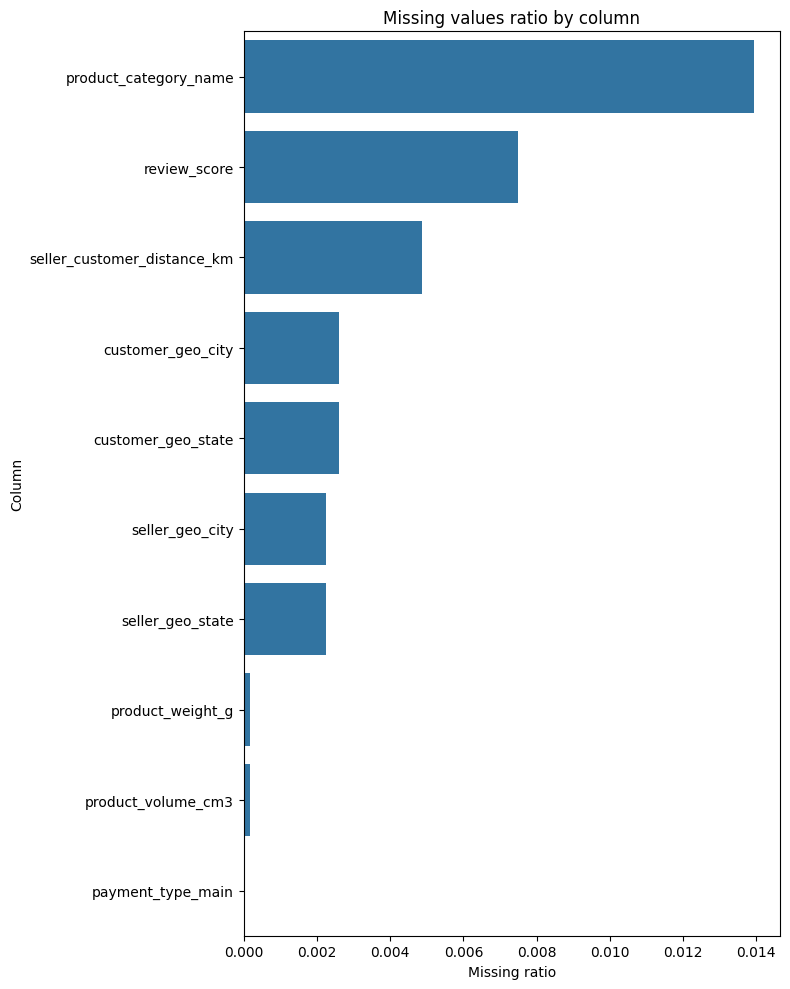

In [10]:
# Plot null ratios
plt.figure(figsize=(8, 10))
sns.barplot(x=nulls[nulls > 0], y=nulls[nulls > 0].index)
plt.title("Missing values ratio by column")
plt.xlabel("Missing ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Missing values - main observations:

- Some columns have a non‑negligible proportion of missing values, especially date fields related to delivery and review text fields.
- Columns with missing values are mostly expected (e.g. orders not delivered or without reviews), so they are likely informative rather than random noise.
- There are no columns with an extremely high null ratio that would be immediate candidates for dropping at this stage.
- We will need to handle missing values carefully during feature engineering, possibly with separate indicators (flags) for “missing” where it makes business sense.

## Time series analysis

> **Note:** This analysis was removed from the final EDA due to target leakage.  
> The columns `delay_vs_estimated_days` and `order_purchase_timestamp` were dropped  
> in the ETL pipeline (`select_features`) to prevent data leakage into the model.

### Main findings (pre-ETL analysis)
- `delay_vs_estimated_days` shows a right tail of late deliveries, with many orders delivered slightly before or near the estimated date.
- Small positive delays are relatively common; very large delays are less frequent but present.
- Split by `is_late`, late orders show a higher median delay and wider spread — validating `is_late` as a reliable binary target.
- A notable spike in delays occurred between late 2017 and Q1 2018.

In [11]:
# Aggregate late rate by customer state
state_late = (
    df[df["is_late"].notna()]
    .groupby("customer_state")
    .agg(
        total_orders=("is_late", "count"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)

state_late["late_rate"] = state_late["late_orders"] / state_late["total_orders"]
state_late = state_late.sort_values("late_rate", ascending=False)

state_late

,total_orders,late_orders,late_rate
customer_state,,,
AL,427,103,0.241218
MA,800,163,0.20375
SE,375,61,0.162667
PI,523,81,0.154876
CE,1426,218,0.152875
BA,3683,504,0.136845
RJ,14146,1835,0.129719
PA,1054,131,0.124288
TO,310,38,0.122581


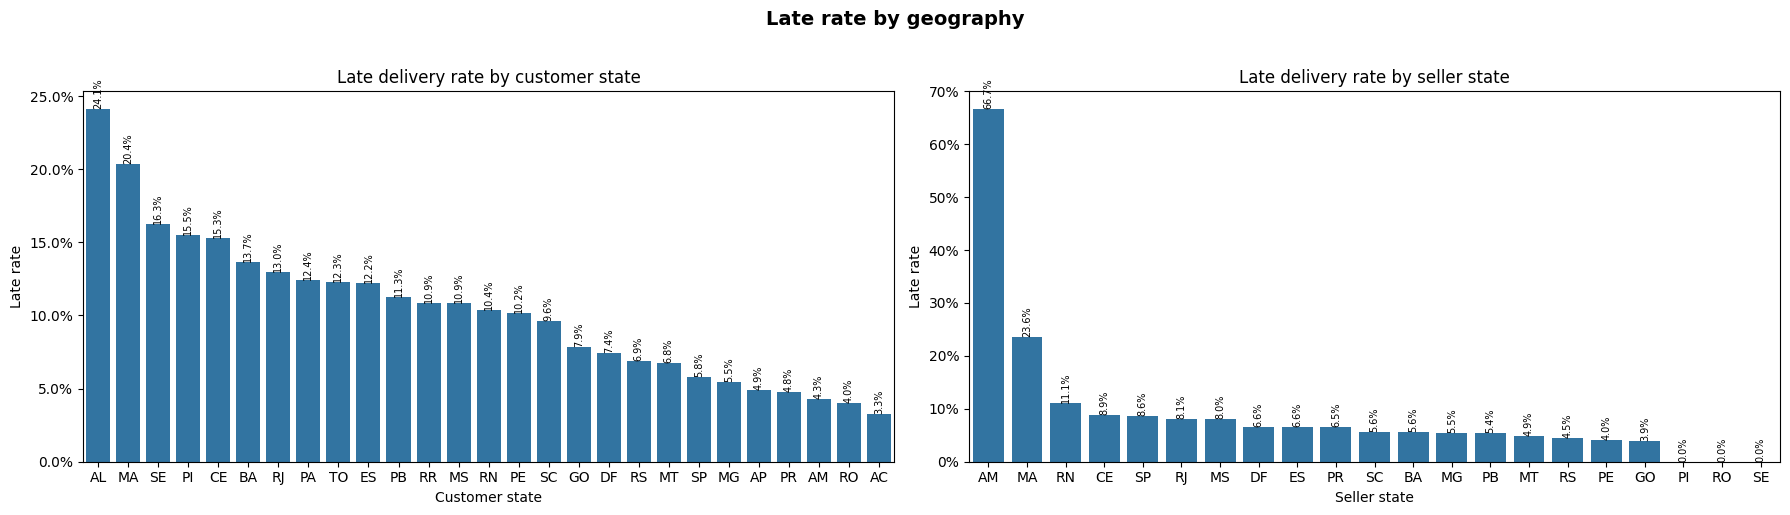

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Customer state ---
sns.barplot(
    data=state_late.reset_index(),
    x="customer_state",
    y="late_rate",
    order=state_late.index,
    ax=axes[0]
)

# Percentual annotations
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[0].set_title("Late delivery rate by customer state")
axes[0].set_xlabel("Customer state")
axes[0].set_ylabel("Late rate")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# --- Seller state ---
seller_state_late = (
    df[df["is_late"].notna()]
    .groupby("seller_geo_state")
    .agg(
        total_orders=("is_late", "count"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)
seller_state_late["late_rate"] = (
    seller_state_late["late_orders"] / seller_state_late["total_orders"]
)
seller_state_late = seller_state_late.sort_values("late_rate", ascending=False)

sns.barplot(
    data=seller_state_late.reset_index(),
    x="seller_geo_state",
    y="late_rate",
    order=seller_state_late.index,
    ax=axes[1]
)

# Percentual annotations
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[1].set_title("Late delivery rate by seller state")
axes[1].set_xlabel("Seller state")
axes[1].set_ylabel("Late rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.suptitle("Late rate by geography", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
df["seller_customer_distance_km"].describe()

count    109660.000000
mean        595.095925
std         586.590301
min           0.000000
25%         184.987858
50%         431.556729
75%         790.517916
max        8652.119722
Name: seller_customer_distance_km, dtype: float64

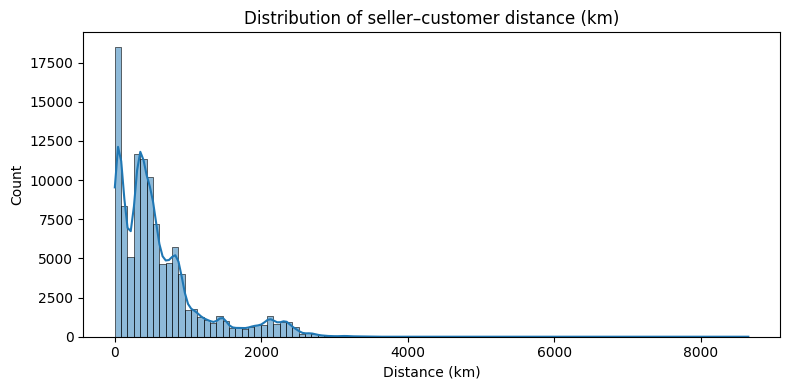

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="seller_customer_distance_km",
    bins=100,
    kde=True
)
plt.title("Distribution of seller–customer distance (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

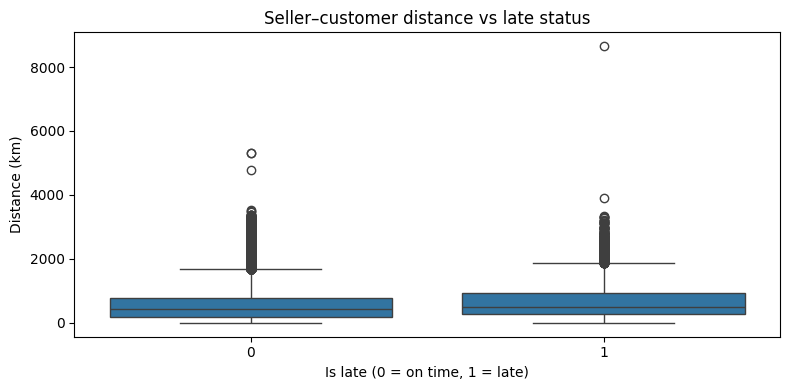

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="is_late",
    y="seller_customer_distance_km"
)
plt.title("Seller–customer distance vs late status")
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

  distance_bucket_km  total_orders  late_rate
0             0–50km         13469     0.0663
1           50–200km         14704   0.060392
2          200–500km         34825   0.070007
3           500km–1k         29449   0.082516
4              1k–2k         11030   0.106346
5              2k–5k          6180   0.135922
6                5k+             3   0.333333


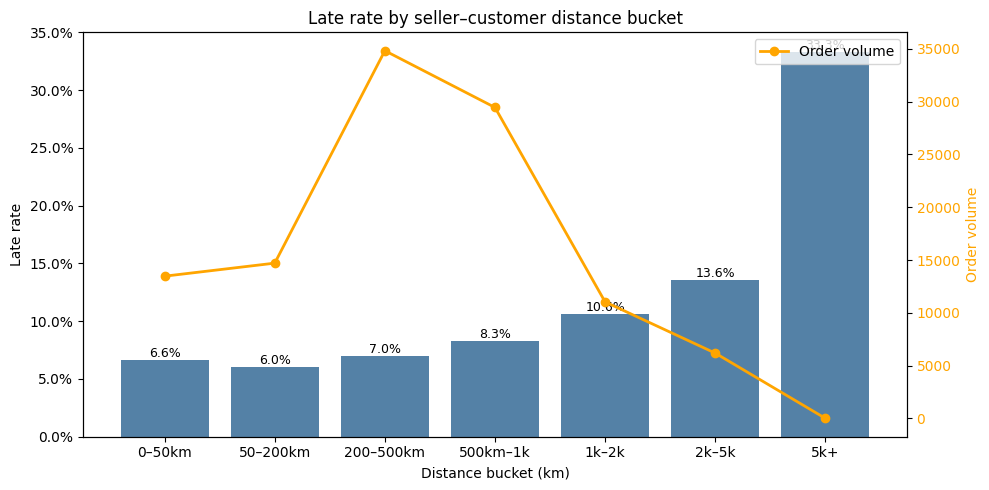

In [16]:
# Filter out NA before bucketing
df_geo = df[df["is_late"].notna() & df["seller_customer_distance_km"].notna()].copy()

# Late rate by distance bucket
bins   = [0, 50, 200, 500, 1000, 2000, 5000, 10000]
labels = ["0–50km", "50–200km", "200–500km", "500km–1k", "1k–2k", "2k–5k", "5k+"]

df_geo["distance_bucket_km"] = pd.cut(
    df_geo["seller_customer_distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

distance_late = (
    df_geo
    .groupby("distance_bucket_km", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", lambda x: (x == 1).sum() / len(x))  # evita ambiguidade do NA
    )
    .reset_index()
)

print(distance_late)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=distance_late,
    x="distance_bucket_km",
    y="late_rate",
    color="steelblue",
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_title("Late rate by seller–customer distance bucket")
ax1.set_xlabel("Distance bucket (km)")
ax1.set_ylabel("Late rate")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    distance_late.index,
    distance_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Geolocation analysis – main findings:

- **Distance matters**: Although the boxplot indicates similar behavior in within late or not orders, the barplot shows that the distance between seller and customer has a clear relationship with late deliveries; larger distance buckets exhibit significantly higher late rates compared to local/regional deliveries.
- **Seller hotspot of delays**: the seller state with the highest late rate, by a wide margin, is **Amazonas (AM)**, suggesting relevant logistical challenges for shipments originating from this region.
- **Customer hotspots of delays**: customer states in the **Northeast** concentrate some of the highest late rates in the dataset, indicating potential bottlenecks in the delivery network to that region.
- These findings reinforce the importance of including **geography and seller–customer distance** as core features in the delay prediction model.

In [17]:
cols_size = [
    "product_weight_g",
    "product_volume_cm3",
    "is_heavy_product",
    "is_bulky_product",
    "is_late",
]

df_eda = df[cols_size].dropna(subset=["is_late"]).copy()
df_eda["is_late"] = df_eda["is_late"].astype(int)
df_eda.head()

,product_weight_g,product_volume_cm3,is_heavy_product,is_bulky_product,is_late
0,500.0,1976.0,0,0,0
1,400.0,4693.0,0,0,0
2,420.0,9576.0,0,0,0
3,450.0,6000.0,0,0,0
4,250.0,11475.0,0,0,0


In [18]:
df_eda.groupby("is_late")[
    ["product_weight_g", "product_volume_cm3"]
].agg(["mean", "median", "std", "min", "max"]).T

is_late                                0              1
product_weight_g   mean      2064.558736    2381.374412
                   median     700.000000     761.000000
                   std       3689.335335    4292.879951
                   min          0.000000      50.000000
                   max      40425.000000   40425.000000
product_volume_cm3 mean     15050.883435   16602.839472
                   median    6450.000000    6750.000000
                   std      22984.790062   25969.886697
                   min        168.000000     352.000000
                   max     296208.000000  269800.000000

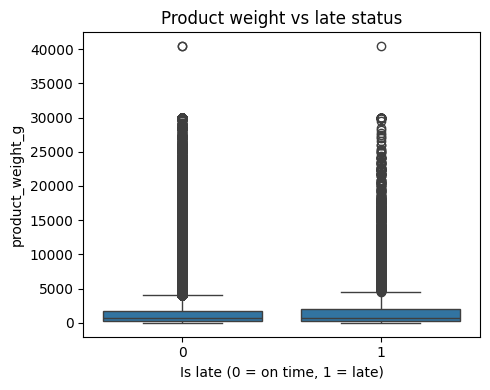

In [19]:
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_eda,
    x="is_late",
    y="product_weight_g",
)
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("product_weight_g")
plt.title("Product weight vs late status")
plt.tight_layout()
plt.show()

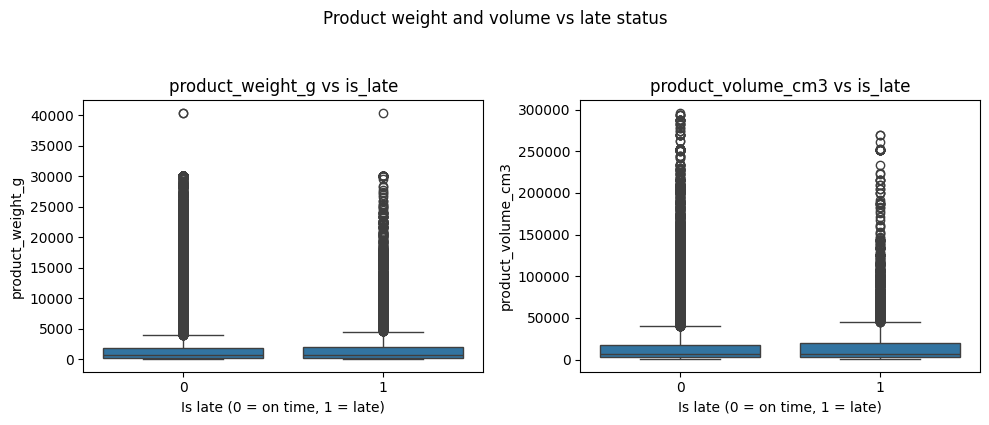

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, feat in zip(axes, ["product_weight_g", "product_volume_cm3"]):
    sns.boxplot(data=df_eda, x="is_late", y=feat, ax=ax)
    ax.set_xlabel("Is late (0 = on time, 1 = late)")
    ax.set_ylabel(feat)
    ax.set_title(f"{feat} vs is_late")

plt.suptitle("Product weight and volume vs late status", y=1.05)
plt.tight_layout()
plt.show()

In [21]:
bins = [0, 1e3, 5e3, 1e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–1k", "1k–5k", "5k–10k", "10k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

vol_late

,product_volume_bucket,total_orders,late_rate
0,0–1k,7828,0.077031
1,1k–5k,40081,0.078591
2,5k–10k,20339,0.073307
3,10k–50k,34706,0.080073
4,50k–100k,5685,0.093755
5,100k+,1539,0.103314


  product_volume_bucket  total_orders  late_rate
0                 0–500          1856   0.089440
1                500–1k          5972   0.073175
2                 1k–2k          9309   0.072618
3                 2k–5k         30772   0.080398
4                5k–10k         20339   0.073307
5               10k–20k         18169   0.079971
6               20k–50k         16537   0.080184
7              50k–100k          5685   0.093755
8                 100k+          1539   0.103314


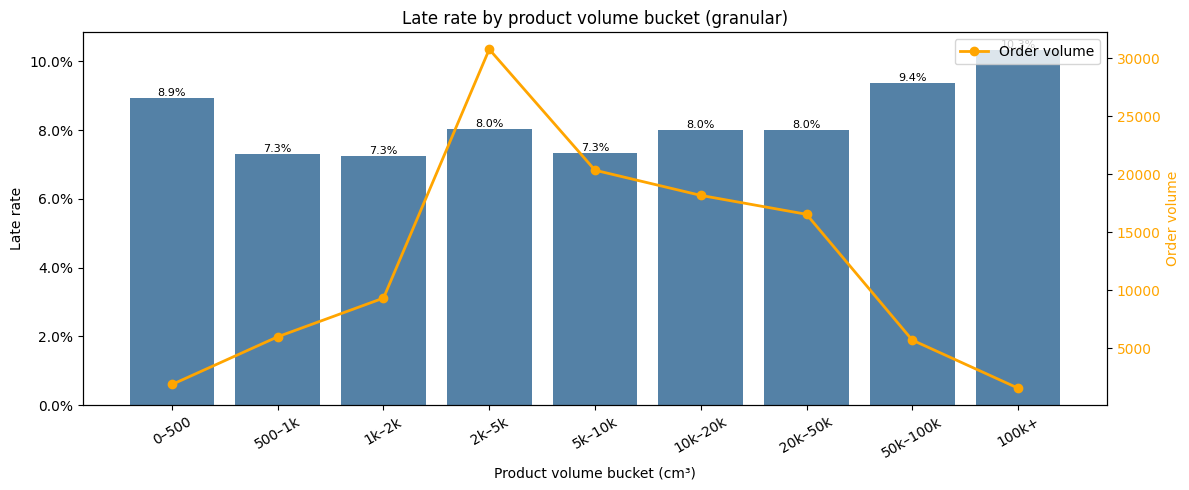

In [22]:
# Late rate by product volume bucket (more granular)
bins   = [0, 500, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–500", "500–1k", "1k–2k", "2k–5k", "5k–10k", "10k–20k", "20k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=vol_late,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=8
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (granular)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(
    vol_late.index,
    vol_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

  product_volume_bucket  total_orders  late_rate
0                 0–50k        102954   0.077928
1                  50k+          7224   0.095792


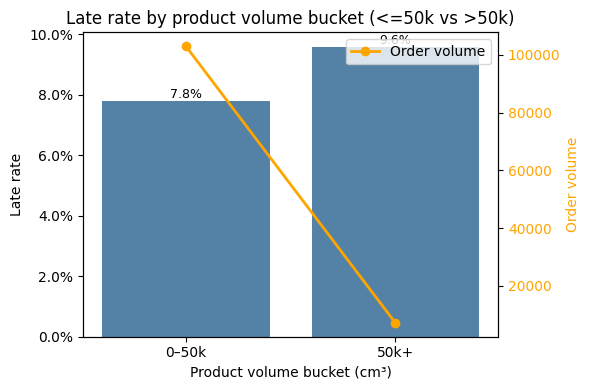

In [23]:
# Late rate by product volume bucket (2 buckets: <=50k and >50k cm³)
bins   = [0, 5e4, df_eda["product_volume_cm3"].max()]
labels = ["0–50k", "50k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late_2 = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late_2)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=vol_late_2,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (<=50k vs >50k)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    vol_late_2.index,
    vol_late_2["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


  product_weight_bucket  total_orders  late_rate
0                 0–10k        105023   0.077773
1                  10k+          5155   0.106111


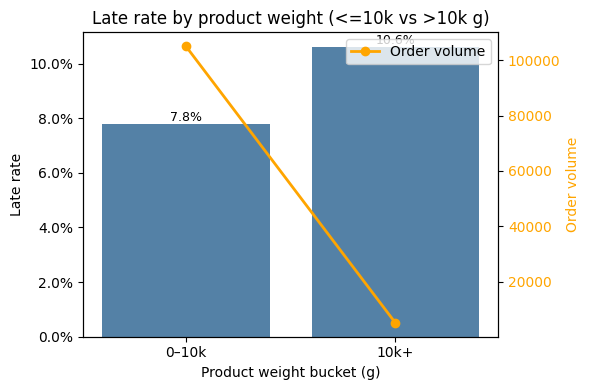

In [24]:
# Late rate by product weight bucket (2 buckets: <=10k and >10k g)
bins   = [0, 1e4, df_eda["product_weight_g"].max()]
labels = ["0–10k", "10k+"]

df_eda["product_weight_bucket"] = pd.cut(
    df_eda["product_weight_g"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

weight_late = (
    df_eda
    .groupby("product_weight_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(weight_late)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=weight_late,
    x="product_weight_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product weight bucket (g)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product weight (<=10k vs >10k g)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    weight_late.index,
    weight_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

                product_category_name  total_orders  late_rate
0                     casa_conforto_2            30   0.166667
1           moveis_colchao_e_estofado            37   0.135135
2                               audio           362   0.127072
3      fashion_underwear_e_moda_praia           127   0.125984
4                    artigos_de_natal           150       0.12
5                     livros_tecnicos           263   0.110266
6                       casa_conforto           429   0.102564
7   construcao_ferramentas_iluminacao           301   0.099668
8                           alimentos           499   0.098196
9                         eletronicos          2729   0.097472
10                       beleza_saude          9467   0.090631
11                  moveis_escritorio          1668   0.089329
12                              bebes          2982    0.08786
13              instrumentos_musicais           651   0.086022
14                   moveis_decoracao          8160   0

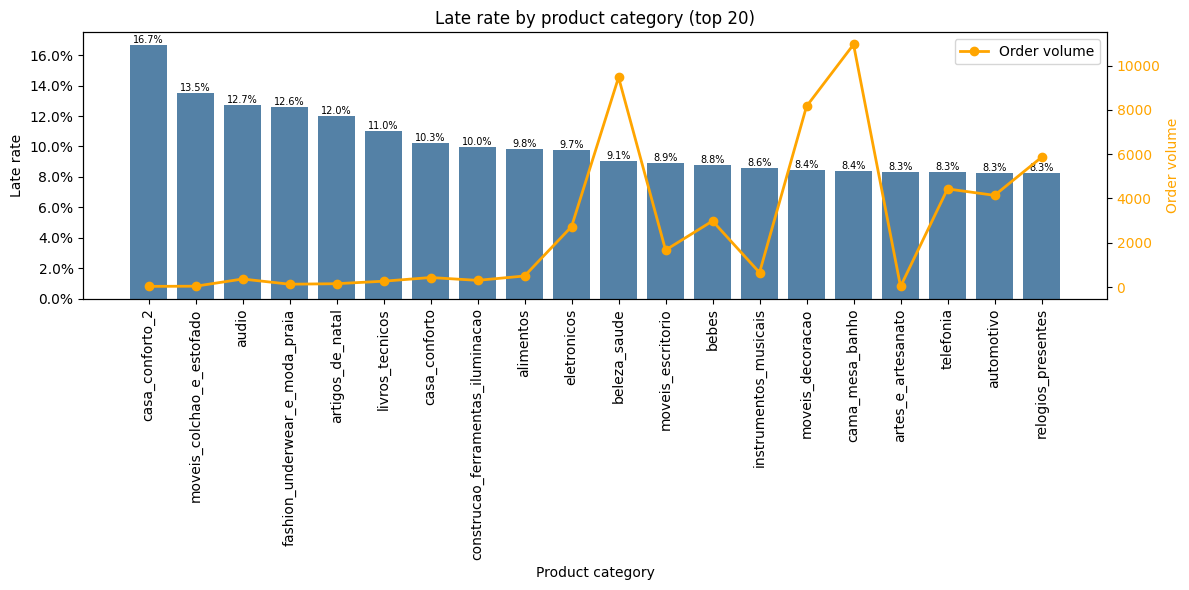

In [25]:
# Late rate by product category
category_late = (
    df[df["is_late"].notna()]
    .groupby("product_category_name")
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(category_late.head(15))

# Plot top 20 categories by late rate
fig, ax1 = plt.subplots(figsize=(12, 6))

top20 = category_late.head(20)

sns.barplot(
    data=top20,
    x="product_category_name",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7
    )

ax1.set_xlabel("Product category")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product category (top 20)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(
    top20.index,
    top20["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Product analysis – main findings

- **Volume and late rate**: the relationship between product volume and late delivery
  rate is not strictly monotonic. Mid-range volumes show comparable late rates to
  larger ones, suggesting volume alone is not a strong linear predictor.

- **Weight threshold**: orders with products weighing more than 10kg show a
  noticeably higher late rate, consistent with the hypothesis that heavier shipments
  face additional logistics constraints (e.g. special handling, carrier restrictions).

- **Feature engineering decision**: both continuous features (`product_weight_g`,
  `product_volume_cm3`) and binary flags (`is_heavy_product`, `is_bulky_product`)
  were retained. This allows linear models to use the thresholds directly while
  tree-based models can explore non-linear interactions.

- **Category late rate**: categories like `moveis_colchao_e_estofado` and
  `fashion_underwear_e_moda_praia` show consistently high late rates with
  sufficient volume to be statistically reliable. Low-volume categories such as
  `casa_conforto_2` should be interpreted with caution as their rates may reflect
  sampling noise rather than a structural pattern.

- **Similar category names**: some categories share near-identical names with a
  numeric suffix (e.g. `casa_conforto` and `casa_conforto_2`). These were
  intentionally kept separate, as the suffix may indicate distinct product lines
  with different logistics profiles. 

- **Feature engineering decision (category)**: given the high cardinality of
  `product_category_name`, target encoding (`category_late_rate`) is preferred
  over one-hot encoding to avoid dimensionality explosion while preserving
  predictive signal.

  payment_type_main  total_orders  late_rate
0            boleto         22362   0.086084
1        debit_card          1651   0.082374
2       credit_card         83220   0.077373
3           voucher          2960   0.071622


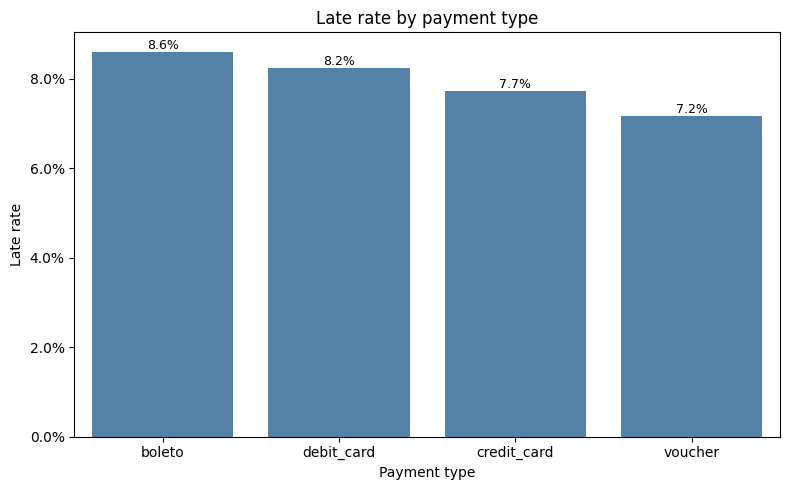

In [26]:
# Late rate by payment type
payment_late = (
    df[df["is_late"].notna()]
    .groupby("payment_type_main")
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(payment_late)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=payment_late,
    x="payment_type_main",
    y="late_rate",
    color="steelblue",
    ax=ax,
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax.set_xlabel("Payment type")
ax.set_ylabel("Late rate")
ax.set_title("Late rate by payment type")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### Payment type & price findings

> **Note:** `price` and `freight_value` were dropped in the ETL pipeline
> to prevent target leakage. Findings below are from pre-ETL analysis.

- **Payment type**: late rates range narrowly from 7.2% (voucher) to 8.6%
  (boleto), suggesting limited standalone predictive signal. Feature retained
  as a low-cost categorical input.

- **Price**: late rate shows a mild positive linear trend with price, rising
  from ~7.1% (lowest decile) to ~9.2% (highest decile). No binary flag needed.

- **Freight value**: carries unique signal from route distance and remote
  delivery zones. Both features were dropped pre-modeling; findings documented
  here for completeness.

In [27]:
# Late rate by seller
seller_late = (
    df[df["is_late"].notna()]
    .groupby("seller_id")
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .query("total_orders >= 30")
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(seller_late.head(20))

                           seller_id  total_orders  late_rate
0   2709af9587499e95e803a6498a5a56e9            46        0.5
1   ede0c03645598cdfc63ca8237acbe73d            47   0.340426
2   54965bbe3e4f07ae045b90b0b8541f52            81   0.320988
3   ad781527c93d00d89a11eecd9dcad7c1            38   0.315789
4   835f0f7810c76831d6c7d24c7a646d4d            48     0.3125
5   2a1348e9addc1af5aaa619b1a3679d6b            51   0.294118
6   66e0557ecc2b4dbea057e93f215f68d8            30   0.266667
7   71039d19d4303bf9054d69e9a9236699            38   0.263158
8   6039e27294dc75811c0d8a39069f52c0            74   0.256757
9   a49928bcdf77c55c6d6e05e09a9b4ca5           104       0.25
10  ef990a83bbea832f36ebe81376335aa8            44       0.25
11  602044f2c16190c2c6e45eb35c2e21cb            55   0.236364
12  06a2c3af7b3aee5d69171b0e14f0ee87           402   0.236318
13  beadbee30901a7f61d031b6b686095ad            68   0.235294
14  cac4c8e7b1ca6252d8f20b2fc1a2e4af            82   0.231707
15  ea56

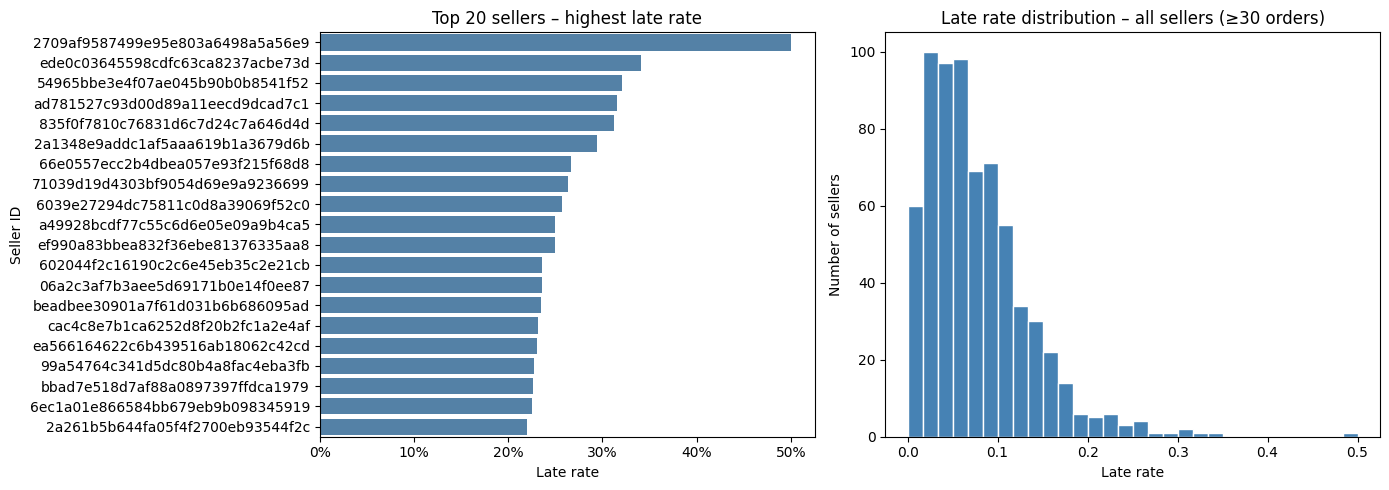

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 worst sellers
sns.barplot(
    data=seller_late.head(20),
    x="late_rate",
    y="seller_id",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Top 20 sellers – highest late rate")
axes[0].set_xlabel("Late rate")
axes[0].set_ylabel("Seller ID")
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Distribution of late rate across all sellers
axes[1].hist(seller_late["late_rate"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Late rate distribution – all sellers (≥30 orders)")
axes[1].set_xlabel("Late rate")
axes[1].set_ylabel("Number of sellers")

plt.tight_layout()
plt.show()

### Seller findings

- **Seller late rate**: distribution is right-skewed, with most sellers concentrated
  between 3–10% late rate. A long tail reaches up to ~34%, indicating that a small
  subset of sellers is responsible for a disproportionate share of delays.
  The top 20 worst sellers range from 21% to 34%, well above the global average.
  Given high cardinality, `seller_id` will be encoded via k-fold target encoding,
  expected to be a strong predictive feature.

In [29]:
review_late = (
    df[df["is_late"].notna()]
    .groupby("review_score")
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(review_late)

   review_score  total_orders  late_rate
0           1.0         12498   0.319731
1           2.0          3672   0.178649
2           3.0          9190   0.103047
3           4.0         21072   0.048738
4           5.0         62937   0.030094


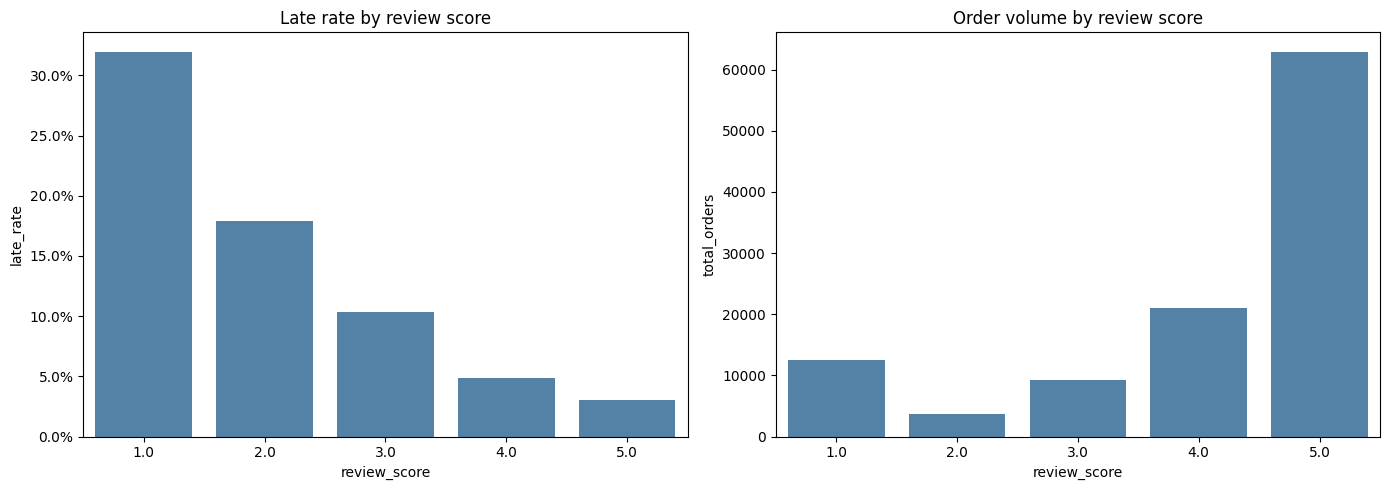

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=review_late,
    x="review_score",
    y="late_rate",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Late rate by review score")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

sns.barplot(
    data=review_late,
    x="review_score",
    y="total_orders",
    color="steelblue",
    ax=axes[1],
)
axes[1].set_title("Order volume by review score")

plt.tight_layout()
plt.show()

### Review score findings

- **Review score**: strong monotonic relationship with late rate. Score 1 reaches
  32% late rate — over 10x higher than score 5 (3%). The relationship is smooth
  and consistent across all levels, confirming `review_score` can be used as a
  continuous numeric feature without encoding. Volume is heavily concentrated
  at score 5 (~63k orders), suggesting most customers are satisfied, while
  dissatisfied reviews are disproportionately driven by late deliveries.

### Review comment findings

> **Note:** `review_comment_message` was dropped in the ETL after
> BERT embeddings were extracted. Findings below are from pre-ETL analysis.

- **Missing rate**: 57.9% of orders have no review comment, making
  `has_comment` a meaningful binary signal on its own (supported by the difference in is_late rate)
- **Comment length**: median 54 chars, max 208 — short texts, well within
  BERT's 512-token limit with no truncation concern.
- **Late rate signal**: orders with comments show ~10.3% late rate vs ~6.1%
  for orders without, suggesting dissatisfied customers are more likely to
  comment. BERT embeddings will capture semantic content beyond this binary
  signal.
- **Feature engineering**: `has_comment` binary flag will be retained
  alongside BERT `[CLS]` embeddings reduced via SVD to ~50 components.

In [31]:
df.head(10)

,order_purchase_timestamp,order_estimated_delivery_date,seller_id,shipping_limit_date,customer_state,review_score,product_category_name,product_weight_g,payment_type_main,seller_geo_city,...,bert_svd_41,bert_svd_42,bert_svd_43,bert_svd_44,bert_svd_45,bert_svd_46,bert_svd_47,bert_svd_48,bert_svd_49,estimated_delivery_dow
0,2017-10-02 10:56:33,2017-10-18,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,SP,4.0,utilidades_domesticas,500.0,voucher,maua,...,-0.098109,0.146767,0.090446,0.280138,-0.106301,-0.437916,0.755499,0.160171,-0.121071,2
1,2018-07-24 20:41:37,2018-08-13,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,BA,4.0,perfumaria,400.0,boleto,belo horizonte,...,0.058410,-0.147710,-0.116853,-0.269182,-0.241428,-0.200264,0.136254,-0.166536,0.043802,0
2,2018-08-08 08:38:49,2018-09-04,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,GO,5.0,automotivo,420.0,credit_card,guariba,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,1
3,2017-11-18 19:28:06,2017-12-15,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,RN,5.0,pet_shop,450.0,credit_card,belo horizonte,...,0.052156,-0.085034,0.380572,0.057153,0.047215,0.005328,-0.367307,-0.231086,0.072944,4
4,2018-02-13 21:18:39,2018-02-26,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,SP,5.0,papelaria,250.0,credit_card,mogi das cruzes,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,0
5,2017-07-09 21:57:05,2017-08-01,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,PR,4.0,automotivo,7150.0,credit_card,guarulhos,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,1
6,2017-05-16 13:10:30,2017-06-07,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,RJ,5.0,automotivo,50.0,credit_card,atibaia,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,2
7,2017-01-23 18:29:09,2017-03-06,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,RS,1.0,moveis_decoracao,300.0,boleto,são josé do rio pardo,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,0
8,2017-07-29 11:55:02,2017-08-23,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,SP,5.0,moveis_escritorio,9750.0,voucher,itaquaquecetuba,...,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148,2
9,2017-05-16 19:41:10,2017-06-07,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,RJ,1.0,ferramentas_jardim,9000.0,credit_card,cariacica,...,-0.028820,0.291094,-0.357852,0.571175,-0.637408,0.125246,-0.050445,-0.539036,-0.075649,2


## Feature Engineering – Round 2

The first modeling round revealed a significant weakness: **low recall for the positive class (late deliveries)**. The model was reasonably good at identifying on-time deliveries but consistently failed to catch actual delays — which is precisely what matters in a logistics context.

To address this, we introduced a second round of feature engineering focused on two areas that the first round had left unexplored: **temporal patterns** and **seller behavior history**.

---

### Seasonality Features

From `order_purchase_timestamp`, we extracted the purchase month, day of week, hour of day, and a binary flag for weekends. The rationale is straightforward: delivery performance is not uniform across time. Orders placed on Fridays, late at night, or during peak months like November and December face different operational conditions than orders placed on a Tuesday morning in March. These features give the model a sense of *when* the purchase happened, not just *what* was bought.

---

### Delivery Pressure Features

Using the gap between `order_purchase_timestamp` and `order_estimated_delivery_date`, we created `estimated_delivery_days` — how many days the customer was promised for delivery. Combined with `seller_customer_distance_km`, this allowed us to compute `km_per_estimated_day`, a proxy for how tight the deadline was relative to the physical distance involved. A high value means the seller had very little time to cover a large distance, which is a direct risk factor for delays.

We also computed `seller_dispatch_window` — the number of days between purchase and the seller's shipping limit — capping it at the 99th percentile (18 days) to remove noise. For `km_per_estimated_day`, we chose to **drop the 5 rows with values above 200** rather than cap them, as these were physically implausible and likely corrupted data points.

---

### Seller Late Rate (Time-Aware)

This is the most important feature of this round. `seller_late_rate` captures each seller's historical delay rate **up to, but not including, the current order**. The calculation uses a chronological sort, a one-period shift, and an expanding mean — ensuring no data leakage. Sellers with no prior history receive the global average late rate as a prior. This gives the model a behavioral signal: some sellers are structurally more likely to be late, regardless of product or distance.

In [42]:
# ── Seasonality features from order_purchase_timestamp ────────────────────────
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["purchase_month"]    = df["order_purchase_timestamp"].dt.month
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek  # 0=Mon, 6=Sun
df["purchase_hour"]     = df["order_purchase_timestamp"].dt.hour
df["purchase_is_weekend"] = df["purchase_dayofweek"].isin([5, 6]).astype(int)

print(df[["purchase_month", "purchase_dayofweek", 
          "purchase_hour", "purchase_is_weekend"]].describe())

       purchase_month  purchase_dayofweek  purchase_hour  purchase_is_weekend
count   110196.000000       110196.000000  110196.000000        110196.000000
mean         6.031753            2.745944      14.748684             0.227014
std          3.230813            1.963225       5.314915             0.418903
min          1.000000            0.000000       0.000000             0.000000
25%          3.000000            1.000000      11.000000             0.000000
50%          6.000000            3.000000      15.000000             0.000000
75%          8.000000            4.000000      19.000000             0.000000
max         12.000000            6.000000      23.000000             1.000000


In [43]:
# ── Parse timestamp columns ────────────────────────────────────────────────────
df["order_purchase_timestamp"]      = pd.to_datetime(df["order_purchase_timestamp"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["shipping_limit_date"]           = pd.to_datetime(df["shipping_limit_date"])

# ── Feature Engineering: Estimated Delivery Pressure ──────────────────────────
df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["seller_dispatch_window"] = (
    df["shipping_limit_date"] - df["order_purchase_timestamp"]
).dt.days

df["km_per_estimated_day"] = (
    df["seller_customer_distance_km"] / df["estimated_delivery_days"].replace(0, pd.NA)
)

print(df[["estimated_delivery_days", "seller_dispatch_window", "km_per_estimated_day"]].describe())

       estimated_delivery_days  seller_dispatch_window  km_per_estimated_day
count            110196.000000           110196.000000         109660.000000
mean                 23.441168                6.432684             23.507552
std                   8.824706                5.481091             20.360397
min                   2.000000                2.000000              0.000000
25%                  18.000000                5.000000              9.345725
50%                  23.000000                6.000000             18.724656
75%                  28.000000                7.000000             31.190035
max                 155.000000             1052.000000            540.757483


In [44]:
# ── Investigate outliers ───────────────────────────────────────────────────────
print("seller_dispatch_window > 30 days:")
print(df[df["seller_dispatch_window"] > 30]["seller_dispatch_window"].describe())

print("\nestimated_delivery_days == 0:")
print((df["estimated_delivery_days"] == 0).sum())

print("\nkm_per_estimated_day > 200:")
print(df[df["km_per_estimated_day"] > 200]["km_per_estimated_day"].describe())


seller_dispatch_window > 30 days:
count     209.000000
mean       48.062201
std        99.245669
min        31.000000
25%        34.000000
50%        36.000000
75%        43.000000
max      1052.000000
Name: seller_dispatch_window, dtype: float64

estimated_delivery_days == 0:
0

km_per_estimated_day > 200:
count      5.000000
mean     282.757827
std      145.939527
min      204.742007
25%      205.187877
50%      206.235940
75%      256.865828
max      540.757483
Name: km_per_estimated_day, dtype: float64


In [45]:
# ── Cap dispatch_window at 99th percentile; drop corrupted km_per_estimated_day rows ──
cap_dispatch = df["seller_dispatch_window"].quantile(0.99)
df["seller_dispatch_window"] = df["seller_dispatch_window"].clip(upper=cap_dispatch)

# Fill NaN in km_per_estimated_day with median, then drop physically impossible values
df["km_per_estimated_day"] = df["km_per_estimated_day"].fillna(
    df["km_per_estimated_day"].median()
)
df = df[df["km_per_estimated_day"] <= 200].reset_index(drop=True)

print(f"Dispatch window cap: {cap_dispatch:.1f} days")
print(f"Shape after dropping corrupted km_per_estimated_day rows: {df.shape}")
print(df[["seller_dispatch_window", "km_per_estimated_day"]].describe())

Dispatch window cap: 18.0 days
Shape after dropping corrupted km_per_estimated_day rows: (110191, 78)
       seller_dispatch_window  km_per_estimated_day
count           110191.000000         110191.000000
mean                 6.346489             23.472523
std                  2.750497             20.219674
min                  2.000000              0.000000
25%                  5.000000              9.404607
50%                  6.000000             18.724656
75%                  7.000000             31.101631
max                 18.000000            189.773842


In [46]:
# ── Seller late rate (time-aware, no leakage) ──────────────────────────────────
df = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

df["seller_late_rate"] = (
    df.groupby("seller_id")["is_late"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Fill NaN (first order of each seller has no history yet) with global mean
global_late_rate = df["is_late"].mean()
df["seller_late_rate"] = df["seller_late_rate"].fillna(global_late_rate)

print(df["seller_late_rate"].describe())
print(f"\nNaNs remaining: {df['seller_late_rate'].isna().sum()}")

count    110191.000000
mean          0.068000
std           0.083787
min           0.000000
25%           0.016295
50%           0.053156
75%           0.090909
max           1.000000
Name: seller_late_rate, dtype: float64

NaNs remaining: 0


In [48]:
# ── Save feature-engineered dataframe to parquet ──────────────────────────────
df.to_parquet("processed_logistics_db.parquet", index=False)

print("Saved successfully.")
print(f"Shape: {df.shape}")

Saved successfully.
Shape: (110191, 78)
